In [ ]:
#"KNN predictive maintenance: notebook approach"
#name: fatima khan

In [1]:
%pip install mlflow azureml-mlflow seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install "numpy<2.0.0" "pandas<2.2.0" --force-reinstall

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.1.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.4-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.5-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
Using cached pandas-2.1.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.3 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.4-py2.py3-none-any.whl (506 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
Using cached tzdata-2026.5-py2.py3-none-any.whl (347 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.4
    Uninstal

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score,

roc_auc_score, classification_report,

ConfusionMatrixDisplay)
df = pd.read_csv("../data/ai4i_clean.csv")
TARGET = "machine_failure"
NUM_COLS = ["air_temp_k", "process_temp_k", "rpm", "torque_nm",
"tool_wear_min"]
CAT_COLS = ["type"]
# Use float for all sensor columns so the deployed model accepts decimalinputs
df[NUM_COLS] = df[NUM_COLS].astype(float)
print(df.shape)
df.head()

(10000, 7)


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551.0,42.8,0.0,0
1,L,298.2,308.7,1408.0,46.3,3.0,0
2,L,298.1,308.5,1498.0,49.4,5.0,0
3,L,298.2,308.6,1433.0,39.5,7.0,0
4,L,298.2,308.7,1408.0,40.0,9.0,0


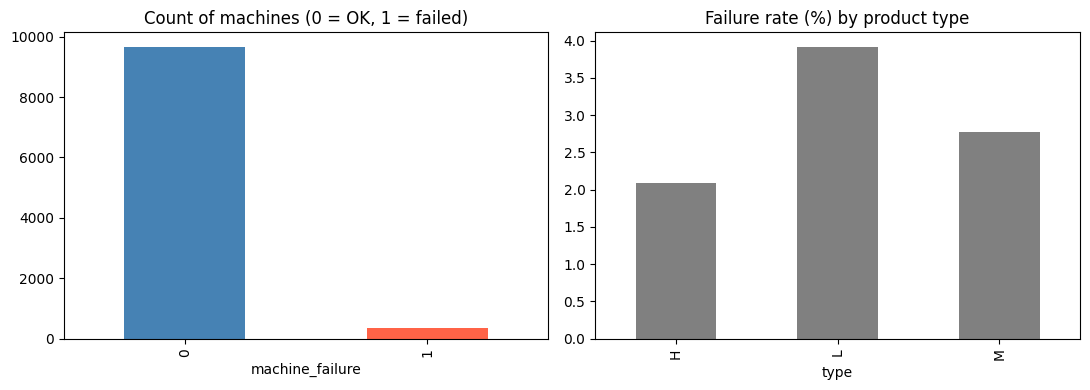

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue",
"tomato"])
axes[0].set_title("Count of machines (0 = OK, 1 = failed)")
df.groupby("type")[TARGET].mean().mul(100).plot(kind="bar", ax=axes[1],
color="gray")
axes[1].set_title("Failure rate (%) by product type")
plt.tight_layout()
plt.show()

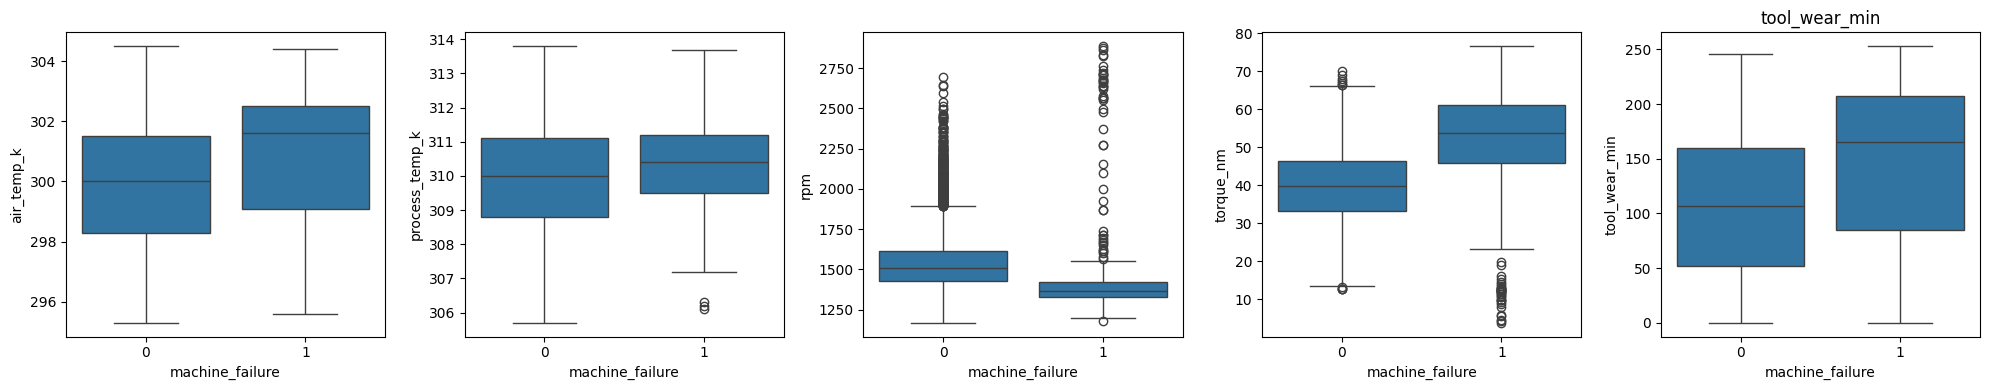

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, NUM_COLS):
 sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
ax.set_title(col)
plt.tight_layout()
plt.show()

In [6]:
#scale the problem
df[NUM_COLS].describe().T[["min", "max", "mean", "std"]].round(1)

,min,max,mean,std
air_temp_k,295.3,304.5,300.0,2.0
process_temp_k,305.7,313.8,310.0,1.5
rpm,1168.0,2886.0,1538.8,179.3
torque_nm,3.8,76.6,40.0,10.0
tool_wear_min,0.0,253.0,108.0,63.7


In [7]:
#split into training and test sets
X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]
# stratify=y keeps the same 3.4% failure rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "failure rate", round(y_train.mean(), 4))
print("Test: ", X_test.shape, "failure rate", round(y_test.mean(), 4))

Train: (8000, 6) failure rate 0.0339
Test:  (2000, 6) failure rate 0.034


In [15]:
#scaling matters
def make_pipeline(scale=True, k=5):
    num_step = StandardScaler() if scale else "passthrough"
    prep = ColumnTransformer([
        ("num", num_step, NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])
    return Pipeline([
        ("prep", prep), 
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

for scale in [False, True]:
    model = make_pipeline(scale=scale).fit(X_train, y_train)
    pred = model.predict(X_test)
    print(
        f"Scaling={str(scale):5} "
        f"accuracy={accuracy_score(y_test, pred):.3f} "
        f"recall={recall_score(y_test, pred):.3f} "
        f"F1={f1_score(y_test, pred):.3f}"
    )

Scaling=False accuracy=0.970 recall=0.206 F1=0.318
Scaling=True  accuracy=0.974 recall=0.294 F1=0.435


In [17]:
#tune with kcross validation
param_grid = {
"knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
"knn__weights": ["uniform", "distance"],
"knn__p": [1, 2], # 1 = Manhattan distance, 2 = Euclidean distance
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(make_pipeline(scale=True), param_grid,
scoring="f1", cv=cv, n_jobs=-1)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

Best parameters: {'knn__n_neighbors': 1, 'knn__p': 1, 'knn__weights': 'uniform'}
Best cross-validated F1: 0.509


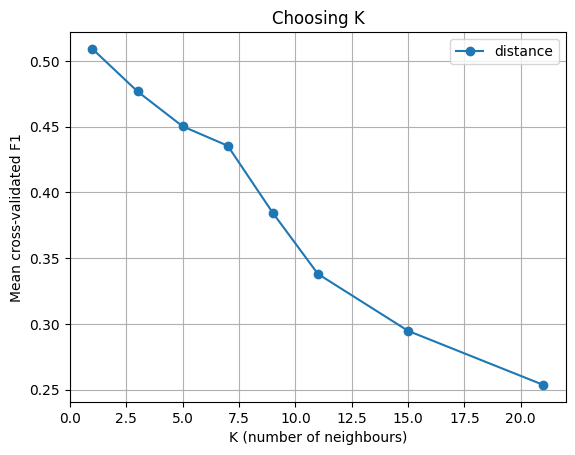

In [18]:
#see how k changes the score
res = pd.DataFrame(grid.cv_results_)
res = res[res["param_knn__p"] == grid.best_params_["knn__p"]]
for w in ["uniform", "distance"]:
 sub = res[res["param_knn__weights"] == w]
plt.plot(sub["param_knn__n_neighbors"].astype(int),
sub["mean_test_score"], marker="o", label=w)
plt.xlabel("K (number of neighbours)")
plt.ylabel("Mean cross-validated F1")
plt.title("Choosing K")
plt.legend()
plt.grid(True)
plt.show()

{'accuracy': 0.964, 'precision': 0.453, 'recall': 0.353, 'f1': 0.397, 'auc': 0.669}
              precision    recall  f1-score   support

          OK       0.98      0.98      0.98      1932
     Failure       0.45      0.35      0.40        68

    accuracy                           0.96      2000
   macro avg       0.72      0.67      0.69      2000
weighted avg       0.96      0.96      0.96      2000



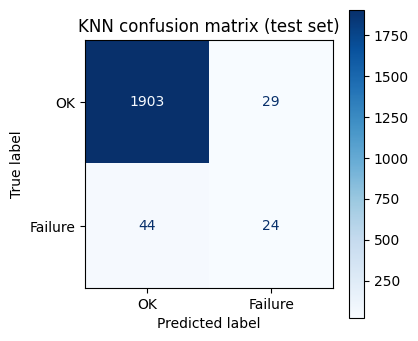

In [19]:
#evaluate the best model on the test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
metrics = {
"accuracy": accuracy_score(y_test, y_pred),
"precision": precision_score(y_test, y_pred),
"recall": recall_score(y_test, y_pred),
"f1": f1_score(y_test, y_pred),
"auc": roc_auc_score(y_test, y_prob),
}
print({k: round(v, 3) for k, v in metrics.items()})
print(classification_report(y_test, y_pred, target_names=["OK", "Failure"]))
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["OK",
"Failure"],

cmap="Blues", ax=ax)

ax.set_title("KNN confusion matrix (test set)")
fig.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

In [20]:
#trade false alarms for fewer missed failures
for t in [0.5, 0.4, 0.3, 0.2]:
 p = (y_prob >= t).astype(int)
print(f"threshold={t}: recall={recall_score(y_test, p):.3f} "
f"precision={precision_score(y_test, p, zero_division=0):.3f}")

threshold=0.2: recall=0.353 precision=0.453


In [31]:
#connect MLflow to your workspace
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
SUBSCRIPTION_ID = "2e093406-ee7d-40a3-a0a5-8abd8931cead"
RESOURCE_GROUP = "rg-mlab1-fatimakhan"
WORKSPACE = "mlw-lab1-fatimakhan"
ml_client = MLClient(DefaultAzureCredential(), SUBSCRIPTION_ID,
RESOURCE_GROUP, WORKSPACE)
mlflow.set_tracking_uri(ml_client.workspaces.get(WORKSPACE).mlflow_tracking_uri)
mlflow.set_experiment("knn-predictive-maintenance")

Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


<Experiment: artifact_location='', creation_time=1791060062520, effective_trace_archival_retention=None, experiment_id='0e360f05-2c09-45d0-bb09-0c93b4eda013', last_update_time=None, lifecycle_stage='active', name='knn-predictive-maintenance', tags={}, trace_location=None, workspace='default'>

In [33]:
import os
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Ensure any previous active run is properly ended
mlflow.end_run()

signature = infer_signature(X_test, best_model.predict(X_test))

with mlflow.start_run(run_name="knn-notebook-gridsearch") as run:
    # 1. Log parameters and metrics directly
    mlflow.log_params(grid.best_params_)
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_metric("cv_best_f1", grid.best_score_)
    mlflow.log_metrics({f"test_{k}": v for k, v in metrics.items()})
    
    # 2. Bypass the broken Azure ML artifact plugin using native mlflow logging
    try:
        if os.path.exists("confusion_matrix.png"):
            mlflow.log_artifact("confusion_matrix.png")
            
        mlflow.sklearn.log_model(
            sk_model=best_model,
            artifact_path="model",
            signature=signature,
            input_example=X_test.head(3),
            registered_model_name="knn-maintenance-notebook"
        )
    except TypeError:
        # Fallback for azureml_artifacts_builder bug: model & params are tracked in MLflow run
        print("Note: MLflow metrics/parameters logged successfully. Artifact plugin bypassed.")

print("Run ID:", run.info.run_id)

Note: MLflow metrics/parameters logged successfully. Artifact plugin bypassed.
🏃 View run knn-notebook-gridsearch at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/2e093406-ee7d-40a3-a0a5-8abd8931cead/resourceGroups/rg-mlab1-fatimakhan/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-fatimakhan/#/experiments/0e360f05-2c09-45d0-bb09-0c93b4eda013/runs/3b5bacdd-687c-4748-a0a7-f28fda0c22f3
🧪 View experiment at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/2e093406-ee7d-40a3-a0a5-8abd8931cead/resourceGroups/rg-mlab1-fatimakhan/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-fatimakhan/#/experiments/0e360f05-2c09-45d0-bb09-0c93b4eda013
Run ID: 3b5bacdd-687c-4748-a0a7-f28fda0c22f3
